# Tutorial — Loading AVIs and running motion correction

This notebook walks through the **streaming, RAM-bounded** motion-correction
workflow on a multi-AVI recording session:

1. **Discover** numbered AVI files in a folder (`0.avi`, `1.avi`, …).
2. **Concatenate** them into a single time-chunked zarr store.
3. **Motion-correct** the concatenated movie via `CNMFe.fit_mc(...)`. The
   corrected movie is written to a second zarr store; the full movie never
   sits in RAM.
4. **Inspect** the result — shift trajectory, frame-by-frame comparison,
   mean projection before/after.

It stops at the end of motion correction. Downstream extraction (initialisation,
ring background, spatial/temporal updates) is covered by separate notebooks.


## 1. Setup & configuration

Configure the input folder, the output paths, and the recording's
high-pass filter sigma. Edit the `SOURCE_FOLDER` / `SOURCE_PATTERN` lines to
point at your own data.


In [1]:
from pathlib import Path
import shutil
import time

import matplotlib.pyplot as plt
import numpy as np

# --- Input ------------------------------------------------------------------
# Default: a synthetic multi-AVI 'session' built from bundled demo movies so
# this notebook runs out-of-the-box. Replace with your own session folder.
PROJECT_ROOT = Path('D:/code/claude_cnmfe')
SOURCE_FOLDER  = PROJECT_ROOT / 'demo_movies' / 'demo_session'
SOURCE_PATTERN = '*.avi'                  # numeric stems: 0.avi, 1.avi, ...

# --- Real recording example (uncomment + edit) ------------------------------
SOURCE_FOLDER  = Path('D:/code/claude_cnmfe/real_vids/20260511_m0009937_wt_1618')
SOURCE_PATTERN = '*.avi'

# --- Output -----------------------------------------------------------------
CONCAT_ZARR = SOURCE_FOLDER / 'session.zarr'   # all AVIs streamed into one zarr
OUTPUT_DIR  = SOURCE_FOLDER / 'mc_output'      # MC writes mc.zarr here

print(f'SOURCE_FOLDER : {SOURCE_FOLDER}')
print(f'CONCAT_ZARR   : {CONCAT_ZARR}')
print(f'OUTPUT_DIR    : {OUTPUT_DIR}')


SOURCE_FOLDER : D:\code\claude_cnmfe\real_vids\20260511_m0009937_wt_1618
CONCAT_ZARR   : D:\code\claude_cnmfe\real_vids\20260511_m0009937_wt_1618\session.zarr
OUTPUT_DIR    : D:\code\claude_cnmfe\real_vids\20260511_m0009937_wt_1618\mc_output


### 1a. Synthesize a demo recording session (only if using default path)

If `SOURCE_FOLDER` is the default `demo_movies/demo_session/` and it doesn't
yet contain numbered AVIs, copy two of the bundled `realistic_medium*.avi`
files into it as `0.avi` and `1.avi`. This gives the rest of the notebook a
realistic multi-file session to chew on. Skip this cell entirely when
pointing at your own data.


In [2]:
DEFAULT_DEMO_SESSION = PROJECT_ROOT / 'demo_movies' / 'demo_session'

if SOURCE_FOLDER == DEFAULT_DEMO_SESSION:
    SOURCE_FOLDER.mkdir(parents=True, exist_ok=True)
    src_a = PROJECT_ROOT / 'demo_movies' / 'realistic_medium.avi'
    src_b = PROJECT_ROOT / 'demo_movies' / 'realistic_medium_long.avi'
    dst_a = SOURCE_FOLDER / '0.avi'
    dst_b = SOURCE_FOLDER / '1.avi'
    for src, dst in [(src_a, dst_a), (src_b, dst_b)]:
        if not dst.exists():
            shutil.copy(src, dst)
            print(f'  copied {src.name} -> {dst.name}')
        else:
            print(f'  already present: {dst.name}')
else:
    print('Using custom SOURCE_FOLDER; skipping demo synthesis.')


Using custom SOURCE_FOLDER; skipping demo synthesis.


## 2. Discover AVI files in the session folder

List the AVIs, sort them by the integer in the filename (so `2.avi` precedes
`10.avi`), and print each file's frame count + spatial shape. Files whose
stem isn't purely numeric are ignored — same rule the concatenator uses.


In [3]:
from concat_avis_to_zarr import _count_and_shape, _numeric_key

avis = sorted(SOURCE_FOLDER.glob(SOURCE_PATTERN), key=_numeric_key)
avis = [p for p in avis if _numeric_key(p) >= 0]
assert avis, f'No numerically-named AVIs in {SOURCE_FOLDER}'

print(f'{len(avis)} AVI file(s) found:\n')
total = 0
for p in avis:
    n, H, W = _count_and_shape(p)
    total += n
    print(f'  {p.name:>20s}   {n:>6d} frames   {H}x{W}')
print(f'\n  TOTAL              {total:>6d} frames   {H}x{W}')


10 AVI file(s) found:

                 0.avi     1000 frames   600x600
                 1.avi     1000 frames   600x600
                 2.avi     1000 frames   600x600
                 3.avi     1000 frames   600x600
                 4.avi     1000 frames   600x600
                 5.avi     1000 frames   600x600
                 6.avi     1000 frames   600x600
                 7.avi     1000 frames   600x600
                 8.avi     1000 frames   600x600
                 9.avi     1000 frames   600x600

  TOTAL               10000 frames   600x600


## 3. Concatenate AVIs into a single zarr

A zarr store is the canonical input format for this pipeline: time-chunked,
random-access, blosc-compressed, and never fully loaded into RAM. The
concatenator streams each AVI frame-by-frame into one big `(T, H, W)`
store on disk. `skip_if_exists=True` makes the cell idempotent — rerun it
freely.


In [4]:
from concat_avis_to_zarr import concat_avis_to_zarr

t0 = time.time()
session = concat_avis_to_zarr(
    folder=SOURCE_FOLDER,
    output_path=CONCAT_ZARR,
    pattern=SOURCE_PATTERN,
    chunk_t=200,           # tune for IO/RAM balance; 200 is a good default
    dtype='uint16',         # keep 8-bit on disk; float32 conversion happens in RAM
    grayscale=True,
    skip_if_exists=True,
    verbose=True,
)
print(f'\nelapsed: {time.time() - t0:.1f}s')


Output already exists, reusing: D:\code\claude_cnmfe\real_vids\20260511_m0009937_wt_1618\session.zarr

elapsed: 5.2s


## 4. Open the concatenated zarr and peek

Reload via `cnmfe.io.open_zarr` (lazy, no decode until indexed) and display
four evenly-spaced frames so we can eyeball quality and motion.


shape  : (10000, 600, 600)
chunks : (200, 600, 600)
dtype  : uint16


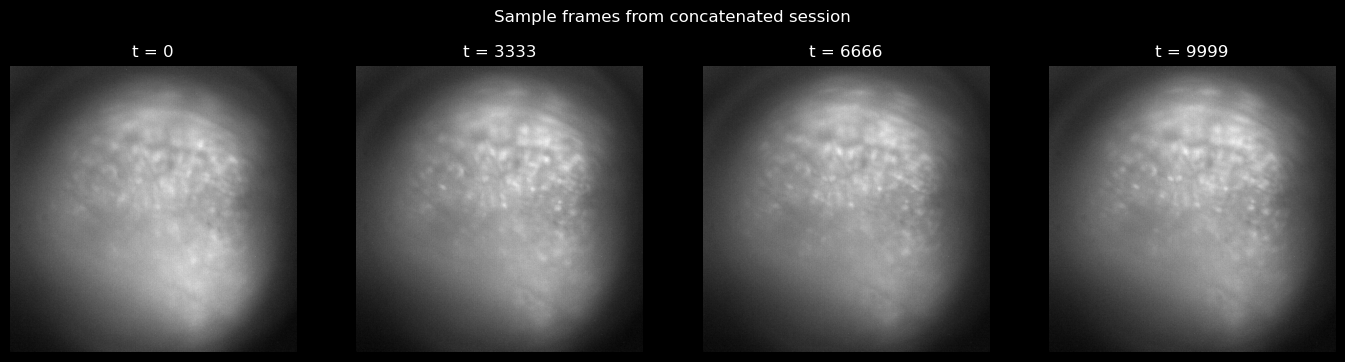

In [5]:
from cnmfe.io import open_zarr

z = open_zarr(CONCAT_ZARR)
T, H, W = z.shape
print(f'shape  : {z.shape}')
print(f'chunks : {z.chunks}')
print(f'dtype  : {z.dtype}')

# Four evenly-spaced sample frames (only these slices are decoded).
sample_idx = np.linspace(0, T - 1, 4).astype(int)
sample = np.stack([np.asarray(z[t]) for t in sample_idx], axis=0)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, t, img in zip(axes, sample_idx, sample):
    ax.imshow(img, cmap='gray')
    ax.set_title(f't = {t}')
    ax.axis('off')
fig.suptitle('Sample frames from concatenated session', y=1.02)
plt.tight_layout()
plt.show()


## 5. Configure motion-correction parameters

The streaming MC path is triggered automatically because the input is a
`zarr.Array`. Key knobs:

- **`max_shift`** — clamp the maximum allowed `(dy, dx)` shift per frame.
- **`mc_gSig_filt`** — sigma of the spatial high-pass filter applied before
  cross-correlation. Required for 1p data (suppresses slow background).
  Set to `None` for 2p.
- **`mc_batch_size`** — frames per streaming/parallel batch. Bigger ≈ faster
  but more RAM.
- **`mc_template_max_frames`** — how many strided frames to sample for the
  median template. Bounds template-step RAM independent of `T`.
- **`n_jobs`** — CPU workers for per-frame work. `-1` = all cores.
- **`upsample_factor`** — subpixel refinement (10 ≈ 0.1 px precision).

Total peak RAM ≈ `(mc_batch_size + mc_template_max_frames) * H * W * 4` bytes.


In [6]:
from cnmfe.pipeline import CNMFe, CNMFeParams

params = CNMFeParams(
    max_shift=(20, 20),
    upsample_factor=10,
    mc_niter_rig=1,                  # 1 pass is the CaImAn default
    mc_gSig_filt=7,                  # 1p high-pass; set to None for 2p
    mc_batch_size=200,
    mc_template_max_frames=2000,
    mc_output_chunk_t=None,          # None = match source chunks
    mc_output_dtype='float32',
    n_jobs=-1,
)

# Quick RAM estimate so you can adjust before kicking off the run.
peak_mb = (params.mc_batch_size + params.mc_template_max_frames) * H * W * 4 / 1e6
print(f'estimated peak RAM (MC step): ~{peak_mb:.0f} MB')


estimated peak RAM (MC step): ~3168 MB


## 6. Run streaming motion correction

`CNMFe.fit_mc(zarr, output_dir=...)` reads the source zarr in batches,
estimates per-frame `(dy, dx)` shifts against a strided-median template,
warps each frame, and writes the corrected frames to
`<output_dir>/mc.zarr`. Peak RAM stays at the estimate above regardless of
total frame count.

The returned object is a `zarr.Array` handle to `mc.zarr`. Shifts live on
`model.shifts` as a `(T, 2)` float32 array.


In [ ]:
model = CNMFe(params)

t0 = time.time()
mc = model.fit_mc(z, output_dir=OUTPUT_DIR)
mc_elapsed = time.time() - t0

print(f'\nMC finished in {mc_elapsed:.1f}s')
print(f'  corrected zarr : {OUTPUT_DIR / "mc.zarr"}')
print(f'  mc.shape       : {mc.shape}')
print(f'  mc.chunks      : {mc.chunks}')
print(f'  mc.dtype       : {mc.dtype}')
print(f'  model.shifts   : {model.shifts.shape}  {model.shifts.dtype}')


## 7. Inspect MC quality

Three checks: the shift trajectory over time, a side-by-side of the
frame with the largest correction (raw vs corrected), and the mean
projection before vs after correction (corrected should be visibly sharper
where neurons sit).


In [ ]:
# 7a. Shift trajectory
shifts = model.shifts                          # (T, 2): (dy, dx) per frame

fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.plot(shifts[:, 0], label='dy', lw=1)
ax.plot(shifts[:, 1], label='dx', lw=1)
ax.set_xlabel('frame')
ax.set_ylabel('shift (px)')
ax.set_title('Per-frame correction shifts')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'  dy : min={shifts[:, 0].min():+.2f}  max={shifts[:, 0].max():+.2f}'
      f'   std={shifts[:, 0].std():.2f}')
print(f'  dx : min={shifts[:, 1].min():+.2f}  max={shifts[:, 1].max():+.2f}'
      f'   std={shifts[:, 1].std():.2f}')


In [ ]:
# 7b. Peak-shift frame: raw vs corrected
peak_t = int(np.argmax(np.linalg.norm(shifts, axis=1)))
raw_peak = np.asarray(z[peak_t], dtype=np.float32)
mc_peak  = np.asarray(mc[peak_t], dtype=np.float32)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].imshow(raw_peak, cmap='gray')
axes[0].set_title(f'raw   (t={peak_t}, shift={shifts[peak_t]})')
axes[0].axis('off')
axes[1].imshow(mc_peak, cmap='gray')
axes[1].set_title('corrected')
axes[1].axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# 7c. Mean projection: raw vs corrected
# Stream both zarrs in batches so we don't materialize the full movies.
def mean_projection(zarr_arr, batch_size=500):
    T = zarr_arr.shape[0]
    acc = np.zeros(zarr_arr.shape[1:], dtype=np.float64)
    for start in range(0, T, batch_size):
        end = min(start + batch_size, T)
        acc += np.asarray(zarr_arr[start:end], dtype=np.float64).sum(axis=0)
    return (acc / T).astype(np.float32)

raw_mean = mean_projection(z)
mc_mean  = mean_projection(mc)

vmin = min(raw_mean.min(), mc_mean.min())
vmax = max(raw_mean.max(), mc_mean.max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].imshow(raw_mean, cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('mean projection (raw)')
axes[0].axis('off')
axes[1].imshow(mc_mean, cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title('mean projection (corrected)')
axes[1].axis('off')
plt.tight_layout()
plt.show()


## 8. Save shifts for later

The shifts are also persisted to `<OUTPUT_DIR>/shifts.npy` so downstream
notebooks (or external analysis) can correlate behavioural events with
frame motion without re-running MC.


In [ ]:
shifts_path = OUTPUT_DIR / 'shifts.npy'
np.save(shifts_path, model.shifts)
print(f'saved -> {shifts_path}')
print(f'         shape={model.shifts.shape}  dtype={model.shifts.dtype}')


## 9. What's next

- The corrected movie lives at `<OUTPUT_DIR>/mc.zarr` as a normal zarr
  store. Reload it lazily later via `open_zarr(...)`.
- For component extraction (init, ring background, spatial/temporal
  updates), see `tutorial2.ipynb` / `tutorial_realistic.ipynb`. Pass
  `do_motion_correction=False` to `CNMFe.fit(...)` when feeding it the
  motion-corrected zarr — no need to redo this step.
- The downstream extraction steps currently require the full corrected
  movie in RAM. For 60k-frame recordings you'll want to subsample, chunk,
  or stream those stages as well (separate effort).
